In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
# from langgraph.prebuilt import ToolNode, tools_conditionc
from langchain_core.tools import tool
from dotenv import load_dotenv
from typing import Literal

In [ ]:

class EmailState(TypedDict):
        input : str
        email_content : str 
        bcc : str 
        subject : str
        max_iteration: int 
        evaluate : Literal["pass","failed"]       


In [31]:

def generate_content(state: EmailState):

    email_content=state["input"]

    return {"email_content":email_content}


def auto_review(state :  EmailState):
    return {"evaluate":"pass"}

def route_evaluation(state : EmailState):

    if((state["evaluate"]=='pass') or state["max_iteration"]>=3):
        return "pass"
    else:
     return "failed"

def optimize(state : EmailState):
   
     return {state["email_content"]:"djsndsifh"}

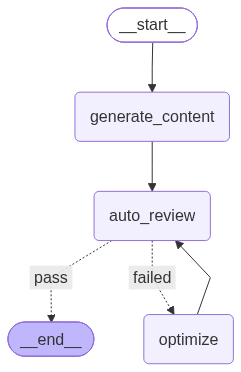

In [ ]:
email_graph =StateGraph(EmailState)
email_graph.add_node("generate_content",generate_content)
email_graph.add_node("auto_review",auto_review)
email_graph.add_node("optimize",optimize)

email_graph.add_edge(START,'generate_content')
email_graph.add_edge("generate_content","auto_review")
email_graph.add_conditional_edges("auto_review",route_evaluation,{"pass":END ,"failed":"optimize"})
email_graph.add_edge("optimize","auto_review")

workflow=email_graph.compile()
workflow
